In [1]:
!pip install -q ultralytics
!pip install -q roboflow
!pip install -q scikit-learn
!pip install -q matplotlib
!pip install -q opencv-python


import os
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict
import pandas as pd

import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.3 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompa

# Данный проект посвящён разработке системы автоматического анализа изображений, полученных с беспилотного летательного аппарата (БПЛА), для выявления дефектов на линиях электропередачи (ЛЭП).

## Решение основано на методах глубокого обучения и компьютерного зрения с использованием архитектуры **YOLOv8**, адаптированной под задачу обнаружения объектов.

## В рамках работы выполняется дообучение (fine-tuning) предобученной модели YOLOv8 на специализированном датасете изображений изоляторов ЛЭП, содержащем как исправные, так и дефектные элементы.

### Система позволяет автоматически:
#### - обнаруживать элементы ЛЭП на изображениях;
#### - выявлять дефекты изоляторов;
#### - визуализировать результаты детекции в виде bounding boxes с классами объектов.

### Практическая значимость проекта заключается в повышении эффективности мониторинга энергетической инфраструктуры за счёт автоматизации процесса анализа данных с БПЛА, что снижает трудозатраты и повышает скорость выявления потенциально опасных дефектов.

## 1. Конвертация аннотаций (VOC XML → YOLO формат)

На данном этапе выполняется подготовка датасета для обучения модели YOLOv8.

Исходные данные представлены в формате VOC XML, где координаты bounding box заданы в абсолютных значениях:
- xmin, ymin — левый верхний угол
- xmax, ymax — правый нижний угол

Для обучения YOLO требуется преобразование в нормализованный формат:
- class_id
- x_center
- y_center
- width
- height

В рамках данного блока выполняется:
- чтение XML-аннотаций
- извлечение координат объектов
- нормализация bounding box относительно размеров изображения
- формирование YOLO-совместимых .txt файлов
- копирование изображений в структуру датасета

In [ ]:
BASE = "/kaggle/input/datasets/danandmaxpro/insulator/InsulatorDataSet-master"
OUT = "/kaggle/working/yolo_dataset"

os.makedirs(f"{OUT}/images", exist_ok=True)
os.makedirs(f"{OUT}/labels", exist_ok=True)

CLASS_MAP = {
    "insulator": 0,
    "defect": 1
}

image_index = {}

for root, dirs, files in os.walk(BASE):
    for f in files:
        if f.lower().endswith(".jpg"):
            image_index[Path(f).stem] = os.path.join(root, f)

annotations = defaultdict(list)

def convert_bbox(img_w, img_h, xmin, xmax, ymin, ymax):

    x = ((xmin + xmax) / 2) / img_w
    y = ((ymin + ymax) / 2) / img_h

    w = (xmax - xmin) / img_w
    h = (ymax - ymin) / img_h

    return x, y, w, h

for root, dirs, files in os.walk(BASE):

    for file in files:

        if not file.endswith(".xml"):
            continue

        xml_path = os.path.join(root, file)

        tree = ET.parse(xml_path)
        xml_root = tree.getroot()

        image_id = xml_root.find("filename").text.strip()

        size = xml_root.find("size")

        img_w = int(size.find("width").text)
        img_h = int(size.find("height").text)

        for obj in xml_root.findall("object"):

            cls = obj.find("name").text.strip().lower()

            if cls not in CLASS_MAP:
                continue

            bbox = obj.find("bndbox")

            xmin = float(bbox.find("xmin").text)
            xmax = float(bbox.find("xmax").text)
            ymin = float(bbox.find("ymin").text)
            ymax = float(bbox.find("ymax").text)

            x, y, w, h = convert_bbox(
                img_w,
                img_h,
                xmin,
                xmax,
                ymin,
                ymax
            )

            annotations[image_id].append(
                f"{CLASS_MAP[cls]} {x} {y} {w} {h}"
            )

for image_id, lines in annotations.items():

    if image_id not in image_index:
        continue

    with open(
        f"{OUT}/labels/{image_id}.txt",
        "w"
    ) as f:
        f.write("\n".join(lines))

    shutil.copy(
        image_index[image_id],
        f"{OUT}/images/{image_id}.jpg"
    )

print("Images:", len(os.listdir(f"{OUT}/images")))
print("Labels:", len(os.listdir(f"{OUT}/labels")))

## 2. Проверка сформированного датасета

На данном этапе выполняется проверка корректности подготовки датасета после конвертации аннотаций.

Проверяется:
- количество изображений
- количество аннотаций (label-файлов)

Данный шаг необходим для подтверждения успешного формирования YOLO-совместимого датасета.

In [ ]:
print(
    "Images:",
    len(os.listdir("/kaggle/working/yolo_dataset/images"))
)

print(
    "Labels:",
    len(os.listdir("/kaggle/working/yolo_dataset/labels"))
)

## 3. Пример YOLO-аннотации

На данном этапе приводится пример сформированной аннотации в формате YOLO.

Каждая строка файла соответствует одному объекту и имеет формат:
**class_id x_center y_center width height**

Данный шаг позволяет визуально проверить корректность преобразования данных.

In [ ]:
with open(
    "/kaggle/working/yolo_dataset/labels/128.txt"
) as f:
    print(f.read())

## 4. Разделение датасета (Train / Validation / Test)

На данном этапе выполняется разделение подготовленного датасета на обучающую, валидационную и тестовую выборки.

Разделение выполняется в соотношении:
- Train — 80%
- Validation — 10%
- Test — 10%

Цель данного этапа — обеспечить корректную оценку качества модели и избежать переобучения.

In [ ]:


ROOT = "/kaggle/working/yolo_dataset"

images = sorted(os.listdir(f"{ROOT}/images"))

train_files, temp_files = train_test_split(
    images,
    test_size=0.2,
    random_state=42
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.5,
    random_state=42
)

for split in ["train", "val", "test"]:

    os.makedirs(f"{ROOT}/images/{split}", exist_ok=True)
    os.makedirs(f"{ROOT}/labels/{split}", exist_ok=True)

def move_split(files, split):

    for img in files:

        txt = img.replace(".jpg", ".txt")

        shutil.move(
            f"{ROOT}/images/{img}",
            f"{ROOT}/images/{split}/{img}"
        )

        shutil.move(
            f"{ROOT}/labels/{txt}",
            f"{ROOT}/labels/{split}/{txt}"
        )

move_split(train_files, "train")
move_split(val_files, "val")
move_split(test_files, "test")

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

## 5. Создание конфигурационного файла data.yaml

На данном этапе формируется конфигурационный файл `data.yaml`, который необходим для обучения модели YOLOv8.

Файл содержит:
- путь к датасету
- разбиение на train / validation / test
- список классов объектов

Данный файл является обязательным для запуска процесса обучения.

In [ ]:
yaml_text = """
path: /kaggle/working/yolo_dataset

train: images/train
val: images/val
test: images/test

names:
  0: insulator
  1: defect
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_text)

print(yaml_text)

## 6. Обучение модели YOLOv8 (Fine-tuning)

На данном этапе выполняется обучение (fine-tuning) предобученной модели YOLOv8 на подготовленном датасете.

Используется модель `yolov8n.pt`, предварительно обученная на COCO-датасете, которая дообучается на задаче обнаружения дефектов ЛЭП.

В процессе обучения:
- модель адаптируется под новые классы (insulator, defect)
- оптимизируются веса нейронной сети
- происходит минимизация функции потерь

In [ ]:
model = YOLO("yolov8n.pt")

results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    patience=10,
    project="powerline_project",
    name="insulator_defect"
)

## 7. Инференс модели на тестовых изображениях

In [ ]:
model = YOLO("/kaggle/working/runs/detect/powerline_project/insulator_defect/weights/best.pt")


results = model.predict(
    source="/kaggle/working/yolo_dataset/images/test",  # тестовые изображения
    conf=0.25,                                           # порог уверенности
    save=True                                            # сохранить результаты
)



## 8. Оценка качества модели на тестовой выборке

После завершения обучения выполняется оценка качества модели на тестовой выборке, которая не использовалась в процессе обучения и валидации.

Для оценки используются следующие метрики:

- Precision (точность)
- Recall (полнота)
- mAP@50
- mAP@50-95

Полученные результаты позволяют объективно оценить способность модели обнаруживать дефекты ЛЭП на новых данных.

In [ ]:
model = YOLO("/kaggle/working/runs/detect/powerline_project/insulator_defect/weights/best.pt")

metrics = model.val(
    data="/kaggle/working/data.yaml",
    split="test"
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

## 9. Визуализация результатов обучения

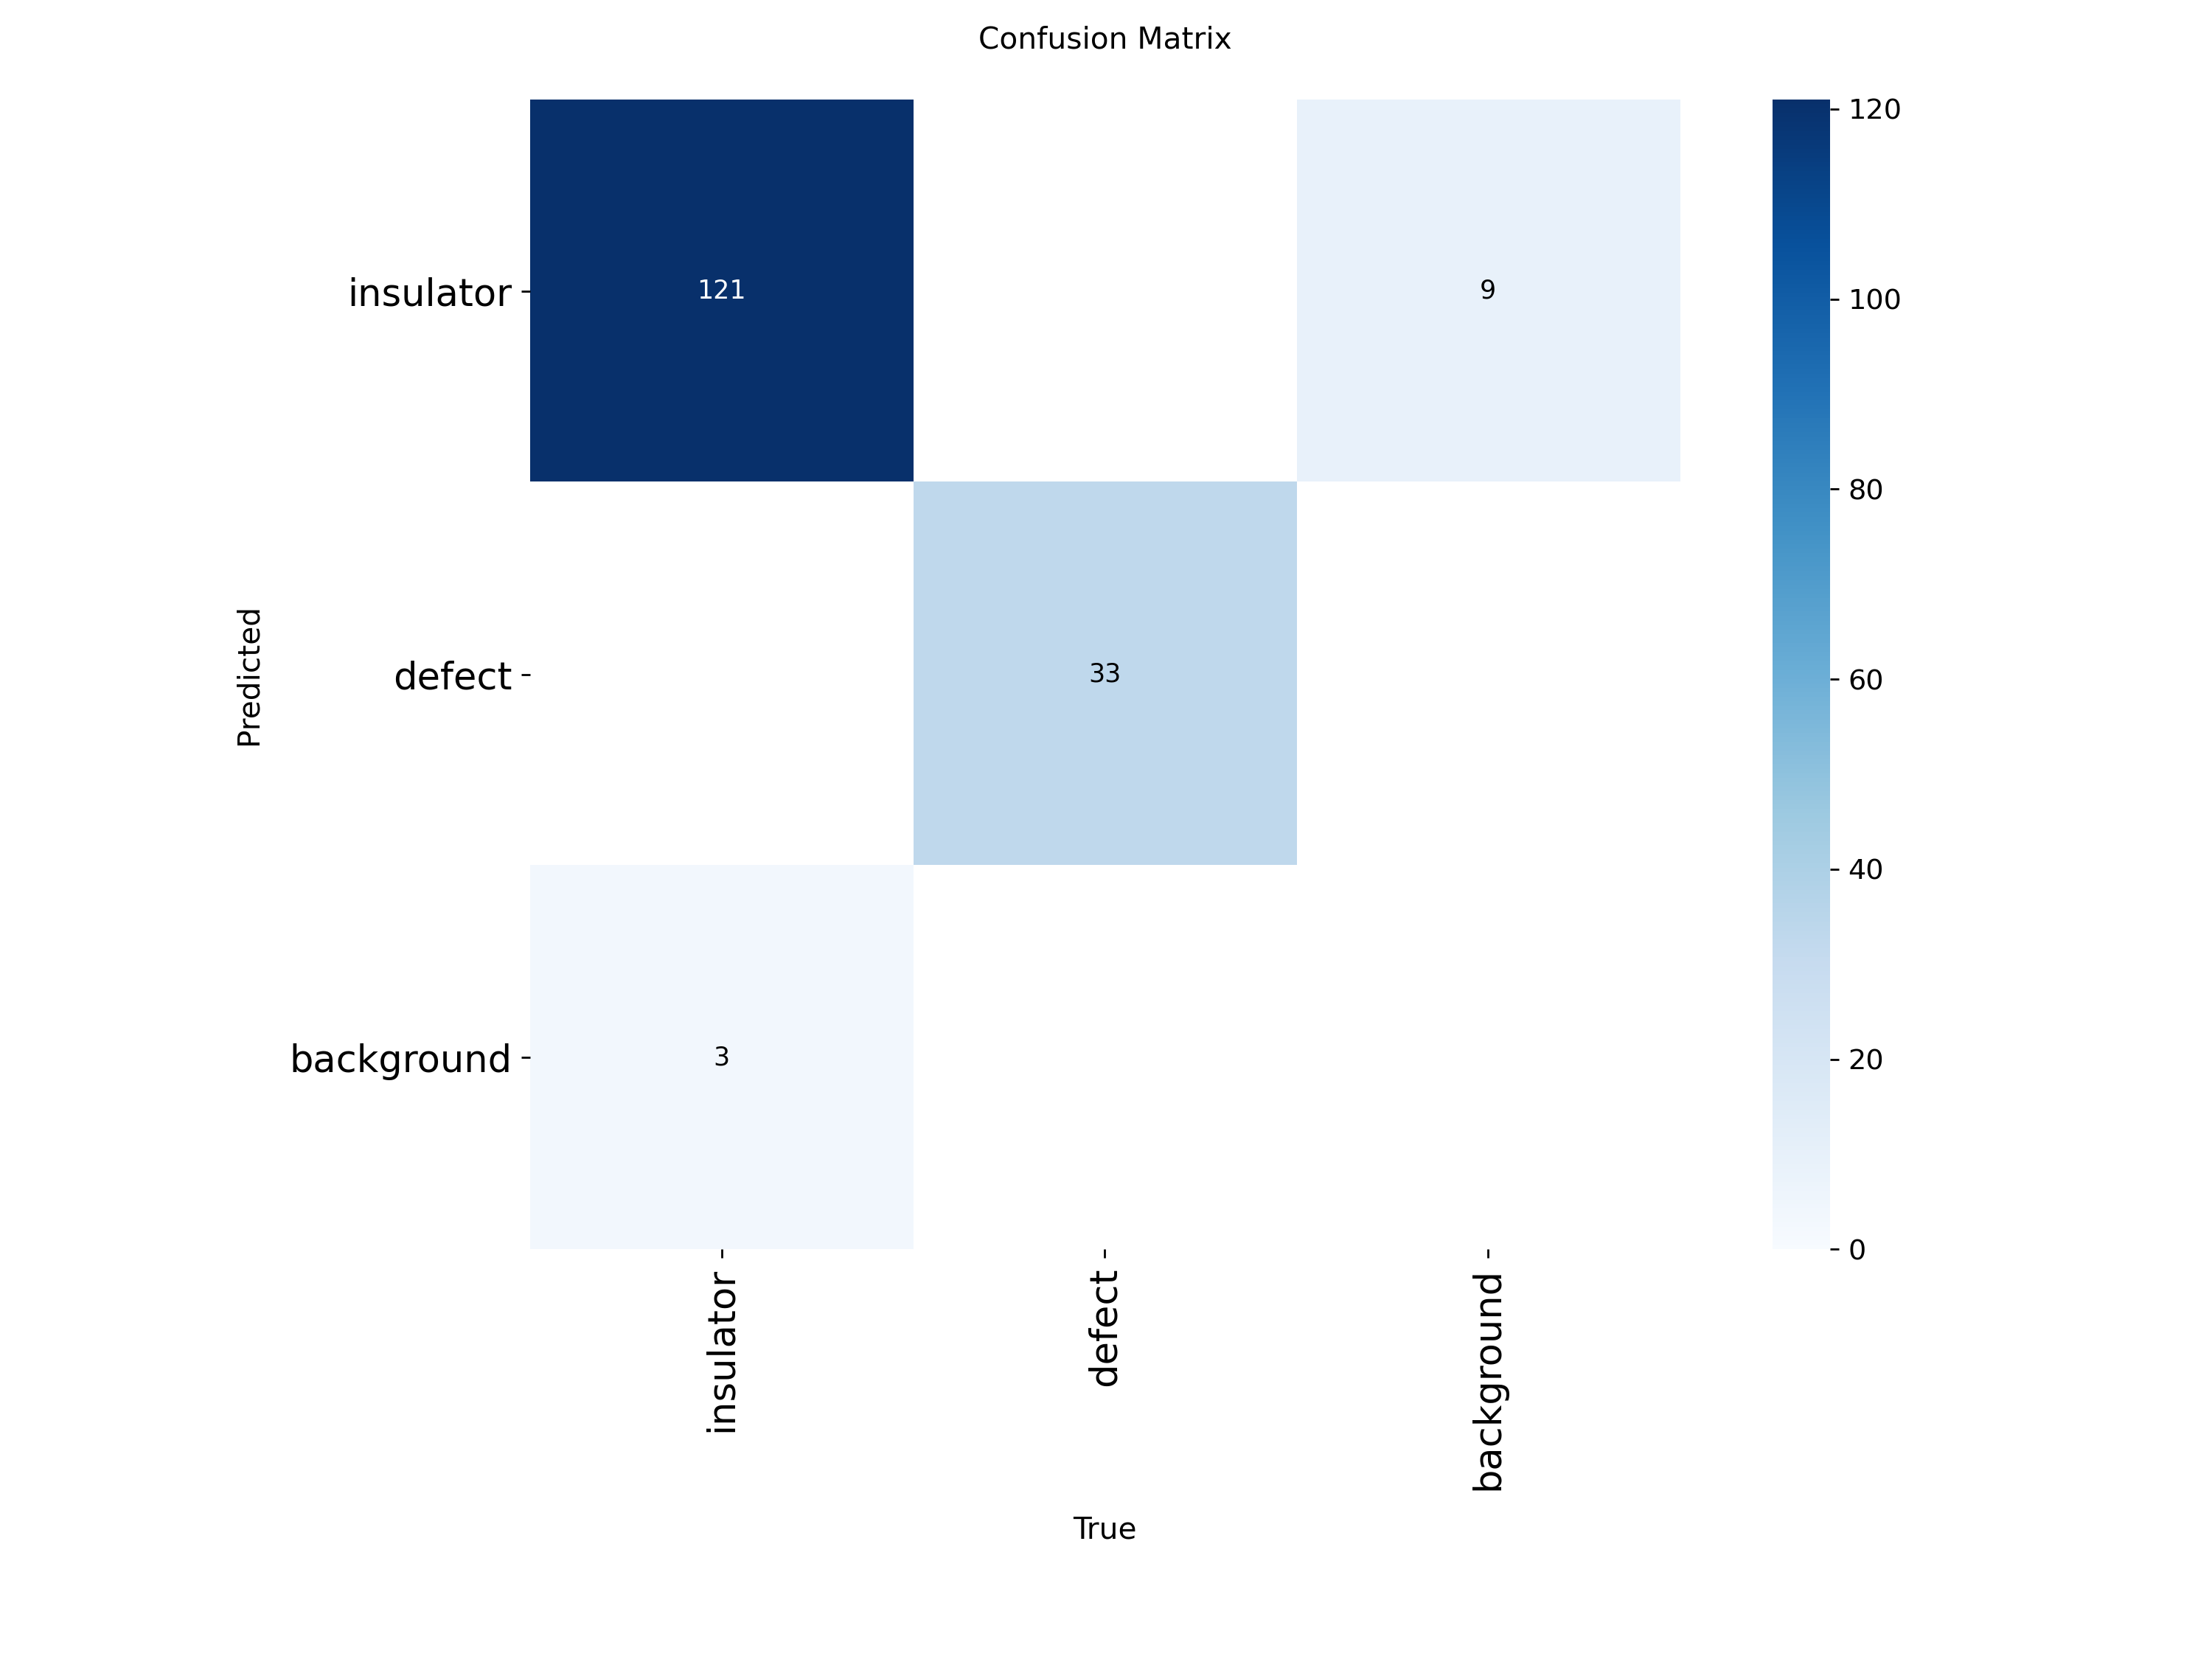

### Матрица ошибок подтверждает высокое качество работы модели. Большинство объектов были отнесены к своим истинным классам, а количество ошибочных классификаций оказалось минимальным. 

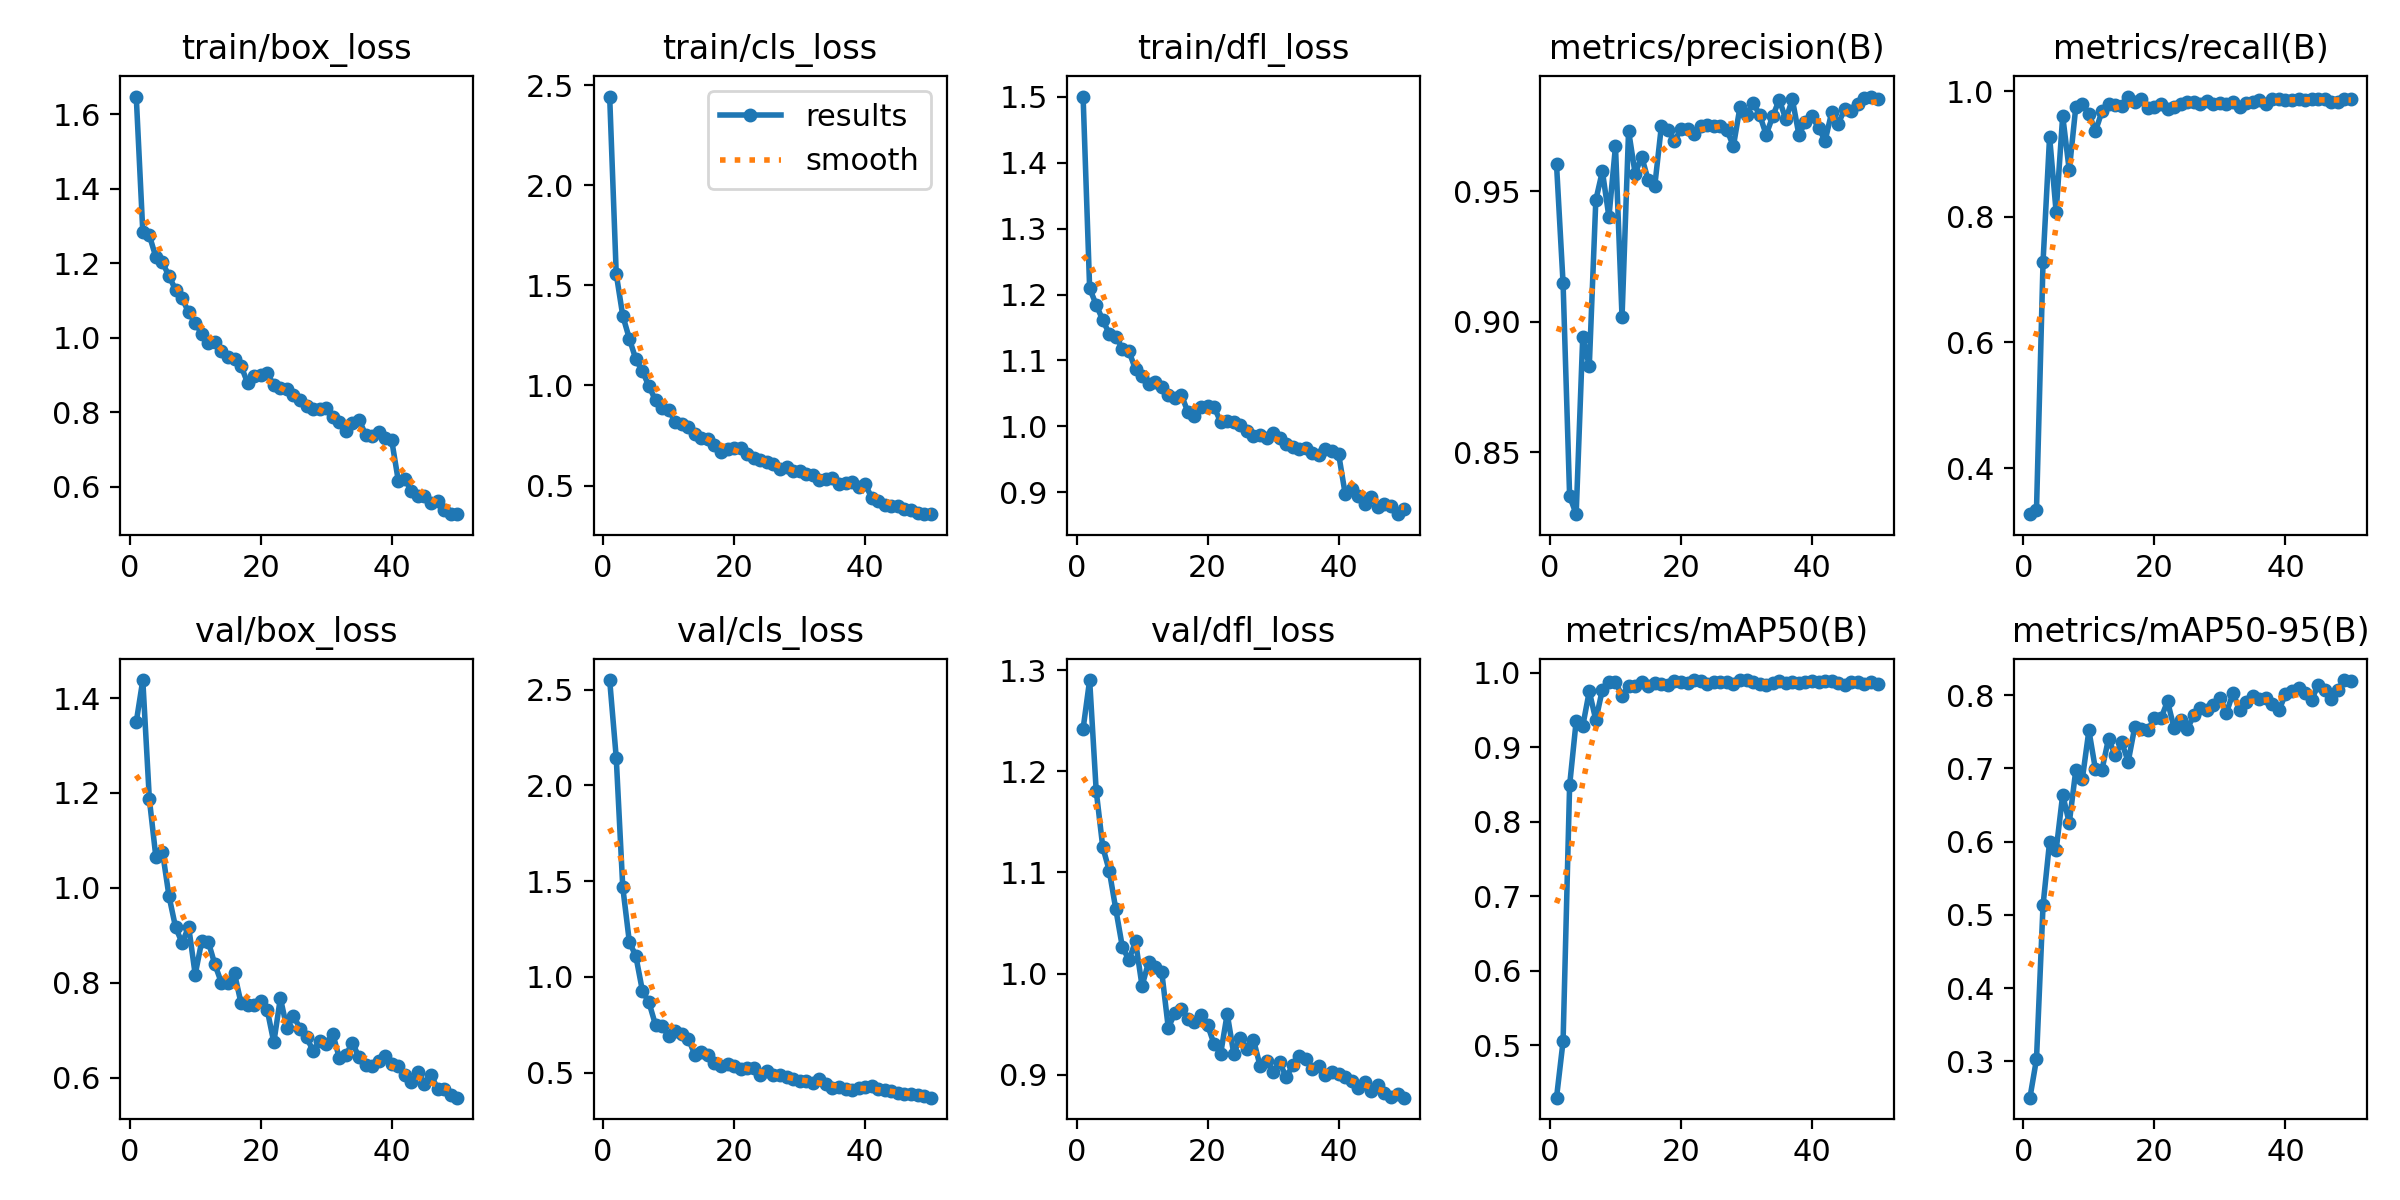

### В ходе обучения наблюдалось устойчивое снижение функции потерь и рост показателей качества. К концу обучения метрики стабилизировались, что свидетельствует о сходимости модели и отсутствии выраженного переобучения.


### Пример разметки 

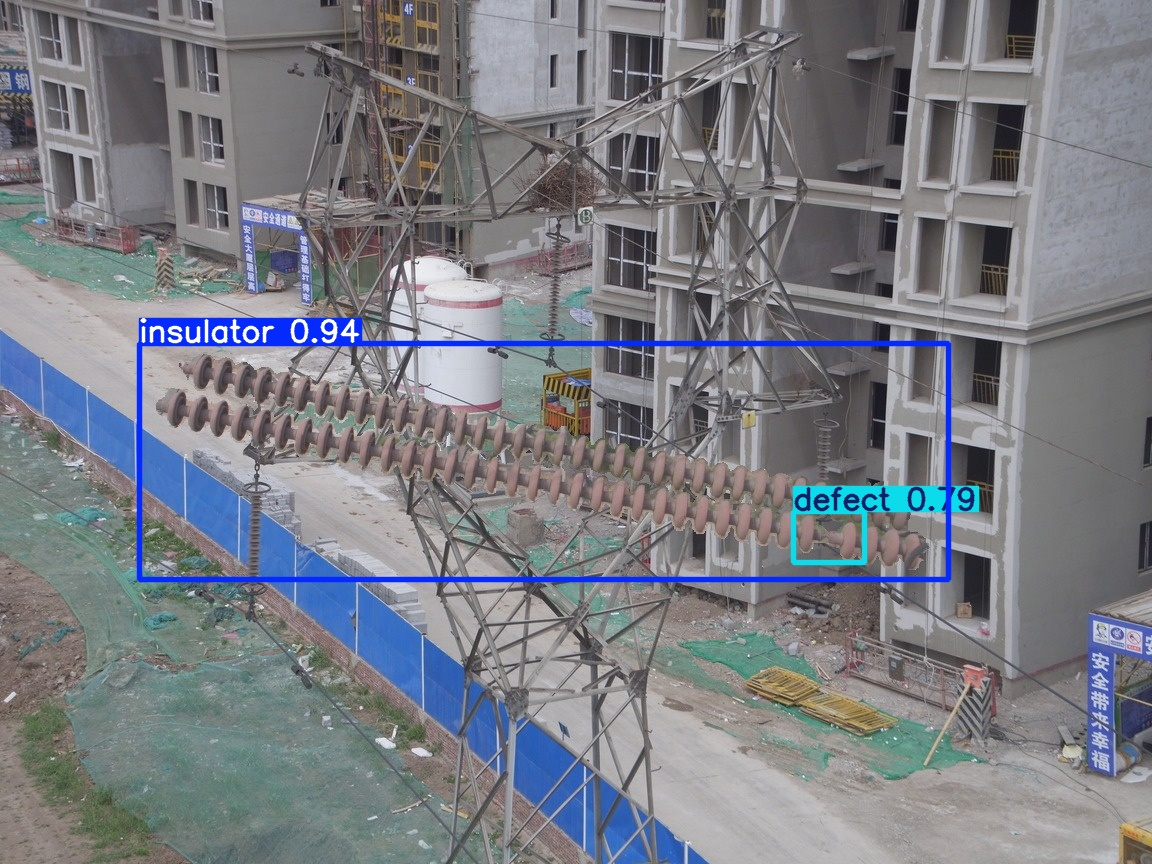

## 10. Обоснование архитектурного выбора: отказ от анализа видеопотока

При разработке системы мониторинга ЛЭП мы провели оценку эффективности методов обработки данных. На основе полученных результатов было принято решение отказаться от прямой обработки видеопотока в пользу **анализа ключевых кадров (Keyframe Extraction)**. Данный выбор обусловлен следующими техническими факторами:

### 1. Проблема доменного сдвига (Domain Shift)

Нейросетевые модели глубокого обучения крайне чувствительны к статистическим характеристикам входных данных. Наша модель была обучена на наборе статических изображений с фиксированным разрешением. Видеопоток с БПЛА обладает иными параметрами сжатия, частотой кадров и, что критично, другим пространственным разрешением. Прямая подача таких данных без сложной процедуры адаптации домена (*domain adaptation*) ведет к резкому снижению метрики средней точности (mAP) и потере предсказательной способности модели.

### 2. Артефакты сжатия и Motion Blur

В отличие от статических снимков, видеопоток содержит динамические искажения, такие как:

* **Motion Blur:** Смазывание объектов при маневрировании дрона.
* **Артефакты кодека:** Потери данных при сжатии видео, которые создают «шум» в высокочастотных деталях изображения.
Использование модели на таких данных привело бы к высокому уровню ложноположительных срабатываний (False Positives), что является недопустимым для систем промышленного контроля критической инфраструктуры.

### 3. Приоритет достоверности данных

Наша система ориентирована на высокоточную диагностику состояния ЛЭП. Мы предпочли сфокусироваться на анализе **статических кадров высокого качества**. Каждый выбранный кадр проходит этап предварительной нормализации (приведение к разрешению, соответствующему обучающей выборке), что гарантирует высокую достоверность каждой детекции и минимизирует вероятность ошибок классификации.


## 11. Генерация отчета

In [ ]:
def process_dataset_to_report(input_folder, output_folder, model_path, report_name="report.csv"):
    model = YOLO(model_path)
    os.makedirs(output_folder, exist_ok=True)
    report_data = []
    
    files = sorted([f for f in os.listdir(input_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"Обработка {len(files)} изображений...")
    
    for filename in files:
        img_path = os.path.join(input_folder, filename)
        results = model.predict(img_path, conf=0.25, verbose=False)
        
        # Сохраняем результат детекции
        save_path = os.path.join(output_folder, f"det_{filename}")
        results[0].save(filename=save_path)
        
        # Если объектов нет, пишем заглушку
        if len(results[0].boxes) == 0:
            report_data.append({"filename": filename, "class": "None", "confidence": 0.0})
        else:
            # Записываем все объекты, найденные на этом фото
            for box in results[0].boxes:
                cls_id = int(box.cls[0])
                report_data.append({
                    "filename": filename,
                    "class": model.names[cls_id],
                    "confidence": round(float(box.conf[0]), 2)
                })
            
    # Создаем DataFrame и сортируем его по имени файла, чтобы объекты с одного фото шли группой
    df = pd.DataFrame(report_data)
    df = df.sort_values(by="filename") 
    
    report_path = os.path.join(output_folder, report_name)
    df.to_csv(report_path, index=False)
    print(f"Отчет сформирован: {report_path}")


In [ ]:
process_dataset_to_report("/kaggle/input/datasets/danandmaxpro/itogfinal2/itog", "/kaggle/working/output/itogFinal2", "/kaggle/input/datasets/danandmaxpro/bestpt/best.pt")

Обработка 11 изображений...
Отчет сформирован: /kaggle/working/output/itogFinal2/report.csv


## Вывод: Итоги реализации системы мониторинга ЛЭП

В ходе работы был разработан автоматизированный пайплайн для анализа состояния ЛЭП на основе компьютерного зрения.

### 1. Архитектура решения

Реализован **end-to-end процесс**: от подготовки размеченных данных до автоматизированной генерации отчетов. Система разделена на логические модули (ядро детекции и аналитический блок), что обеспечивает масштабируемость и простоту интеграции.

### 2. Технологический выбор

Использование модели **YOLOv8** позволило достичь оптимального баланса между высокой скоростью обработки и точностью детекции дефектов, что критически важно для эффективного мониторинга больших участков инфраструктуры.

### 3. Практическая ценность

Система автоматизирует контроль состояния изоляторов, что позволяет:

* **Сократить трудозатраты:** замена ручного просмотра на автоматизированный анализ снимков.
* **Исключить человеческий фактор:** минимизация ошибок при поиске дефектов.
* **Обеспечить отчетность:** автоматическая фиксация каждого инцидента в CSV-отчете с визуальным подтверждением.